In [2]:
## DIFFERENZZE FINITE KOLMOGOROV-FISHER e NAGUMO
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la

In [ ]:
#### risolvo eq differenziale com metodo delle differenze finite IMPLICITO 

### brutti risultati con i dati del 2nd ex . non chiaro come leggere i grafici

Time: 0.03, Max u: 0.5015396736866199, Min u: 2.892772896295137e-69
Time: 0.06, Max u: 1.0, Min u: 2.2137986965607286e-67
Time: 0.09, Max u: 1.0, Min u: 8.563940389472529e-66
Time: 0.12, Max u: 1.0, Min u: 2.2326194754648492e-64
Time: 0.15, Max u: 1.0, Min u: 4.412348735142346e-63
Time: 0.18, Max u: 1.0, Min u: 7.050574592250957e-62
Time: 0.21, Max u: 1.0, Min u: 9.487791093151343e-61
Time: 0.24, Max u: 1.0, Min u: 1.1058200730007913e-59
Time: 0.27, Max u: 1.0, Min u: 1.1394533779855232e-58
Time: 0.30, Max u: 1.0, Min u: 1.0543885850533664e-57
Time: 0.33, Max u: 1.0, Min u: 8.870590210442416e-57
Time: 0.36, Max u: 1.0, Min u: 6.852959235029972e-56
Time: 0.39, Max u: 1.0, Min u: 4.901666119133835e-55
Time: 0.42, Max u: 1.0, Min u: 3.2684239966740253e-54
Time: 0.45, Max u: 1.0, Min u: 2.0436330319585195e-53
Time: 0.48, Max u: 1.0, Min u: 1.2042668982817958e-52
Time: 0.51, Max u: 1.0, Min u: 6.717335200541001e-52
Time: 0.54, Max u: 1.0, Min u: 3.560334097638975e-51
Time: 0.57, Max u: 1.0,

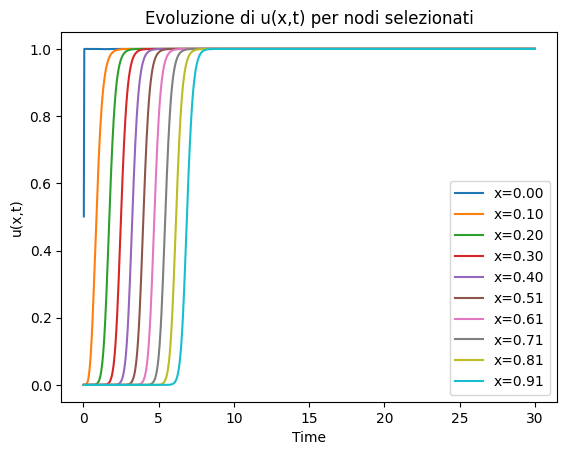

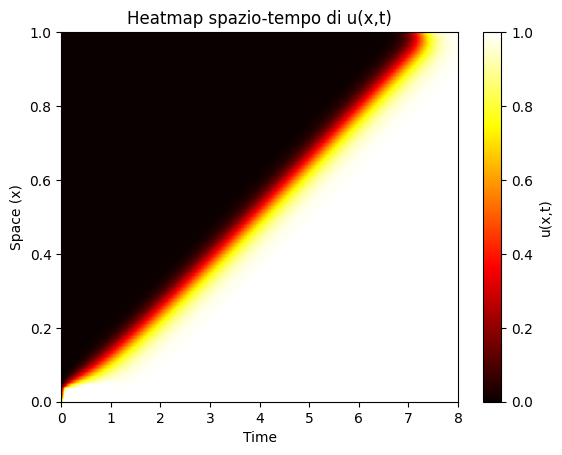

In [ ]:
sigma, b = 1e-3, 5 

n, L = 100, 1  # n di nodi spaziali
m, T = 1000, 30  # dt = 0.15

h = L / n  # passo spaziale 
tau = T / m

x = np.linspace(0, L, n)
t  = np.linspace(0, T, m)

uu = np.zeros(n)

# A matrix con Newuman cond
A = 2 * np.diag(np.ones(n)) - np.diag(np.ones(n - 1), 1) - np.diag(np.ones(n - 1), -1)
A[0, 0] = A[-1, -1] = 1  # neuman ai bordi
A = A* (sigma / h**2)

M = np.eye(n)
M[0, 0] = M[-1, -1] = 1 / 2

A = A + (1 / tau) * M  # coeff di u^k+1 della discretizzazione implicita 

Iap = 10
bb1 = np.zeros(n)    # passi del sistema 
bb1[x <= 0.04] = Iap  # Stimolo nella regione [0, 0.04]


# Simulazione nel tempo

t0 = 0
time = []
results = []

# dynamic graph
plt.ion()
plot_interval = T / 13  # ridurre il numero di grafici
next_plot_time = 0

while t0 <= T:
    t0 += tau

    bb = np.zeros(n)
    if t0 <= 1:         ## CONdizioni nel tempo
        bb += bb1  # aggiungo stimolo iniziale 
    bb += b * uu * (1 - uu)    # termine non lineare  + corrente messa al passo prima 
    bb = M @ ( uu/ tau )  + bb    # uu == soluzione u in t = k 

    uu_new = np.linalg.solve(A, bb)
    uu = np.clip(uu_new, 0, 1)
    print(f"Time: {t0:.2f}, Max u: {np.max(uu)}, Min u: {np.min(uu)}")

# ----------------------------

    # real time plot 
    results.append(uu.copy())
    time.append(t0)


results = np.array(results)

plt.ioff() 

plt.figure(1)
for i in range(0, n, 10):  # Prendi nodi ogni 10
    plt.plot(time, results[:, i], label=f"x={x[i]:.2f}")
plt.xlabel("Time")
plt.ylabel("u(x,t)")
plt.title("Evoluzione di u(x,t) per nodi selezionati")
plt.legend()
plt.show()

# Grafico 2: Heatmap spazio-tempo
plt.figure(2)
plt.imshow(results.T, extent=[0, T, 0, L], origin="lower", aspect="auto", cmap="hot")
plt.colorbar(label="u(x,t)")
plt.xlabel("Time")
plt.ylabel("Space (x)")
plt.xlim(0,8)
plt.title("Heatmap spazio-tempo di u(x,t)")
plt.show()


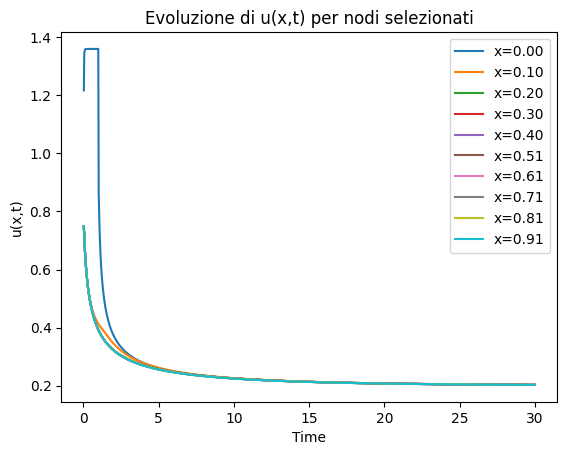

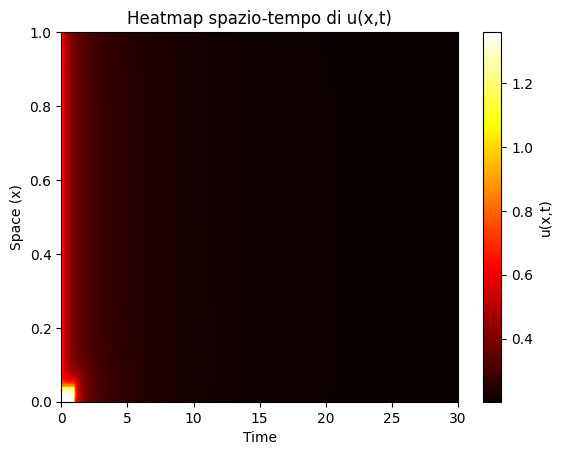

In [21]:
# EX 2 
T, beta, delta = 30, 0.1, 0.2
t0 = 0
time = []
results = []

# dynamic graph
plt.ion()
plot_interval = T / 16  # ridurre il numero di grafici
next_plot_time = 0

Iap = 10
bb1 = np.zeros(n)    # passi del sistema 
bb1[x <= 0.04] = Iap  # Stimolo nella regione [0, 0.04]

while t0 <= T:
    t0 += tau

    bb = np.zeros(n)
    if t0 <= 1:
        bb += bb1  # aggiungo stimolo iniziale 
    bb += b * uu * (uu - beta) * (delta - uu)    # termine non lineare  + corrente messa al passo prima 
    bb = M @ ( uu/ tau )  + bb    # uu == soluzione u in t = k 

    uu_new = np.linalg.solve(A, bb)
    uu = np.clip(uu_new, 0, 2)
   # print(f"Time: {t0:.2f}, Max u: {np.max(uu)}, Min u: {np.min(uu)}")

    # real time plot 
    results.append(uu.copy())
    time.append(t0)


results = np.array(results)

plt.ioff() 

plt.figure(1)
for i in range(0, n, 10):  # Prendi nodi ogni 10
    plt.plot(time, results[:, i], label=f"x={x[i]:.2f}")
plt.xlabel("Time")
plt.ylabel("u(x,t)")
plt.title("Evoluzione di u(x,t) per nodi selezionati")
plt.legend()
plt.show()

# Grafico 2: Heatmap spazio-tempo
plt.figure(2)
plt.imshow(results.T, extent=[0, T, 0, L], origin="lower", aspect="auto", cmap="hot")
plt.colorbar(label="u(x,t)")
plt.xlabel("Time")
plt.ylabel("Space (x)")
#plt.xlim(0,5)
plt.title("Heatmap spazio-tempo di u(x,t)")
plt.show()